<a href="https://colab.research.google.com/github/Bakana1171/daset/blob/main/HealthConnect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Améliorer la présence aux rendez-vous des patients et le support aux patients grâce aux données et à l’IA

### 1. Prise en main du jeu de données

A - Importation des librairies

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

B- Télechargement du fichier

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HealthC.xlsx to HealthC.xlsx


In [ ]:
HC = pd.read_excel('HealthC.xlsx')
HC.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-06-02 00:00:00,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-09-07 00:00:00,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


2. Évaluation de la qualité des données

In [ ]:
HC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

In [ ]:
HC['appointment_date']=pd.to_datetime(HC['appointment_date'],errors='coerce')

In [ ]:
HC['booking_date']=pd.to_datetime(HC['booking_date'],errors='coerce')

In [ ]:
HC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   appointment_id         5000 non-null   object        
 1   patient_id             5000 non-null   object        
 2   gender                 5000 non-null   object        
 3   age                    5000 non-null   int64         
 4   age_group              5000 non-null   object        
 5   appointment_type       5000 non-null   object        
 6   booking_date           5000 non-null   datetime64[ns]
 7   appointment_date       5000 non-null   datetime64[ns]
 8   appointment_day        5000 non-null   object        
 9   appointment_time       5000 non-null   object        
 10  booking_lead_days      5000 non-null   int64         
 11  previous_appointments  5000 non-null   int64         
 12  previous_no_shows      5000 non-null   int64         
 13  rem

In [ ]:
HC.describe()

,age,booking_date,appointment_date,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
count,5000.000000,5000,5000,5000.00000,5000.000000,5000.000000,4910.000000,4940.000000
mean,48.794800,2025-09-09 02:37:49.440000,2025-10-11 02:50:29.760000,29.63860,3.013800,0.544200,10.109572,24.189676
min,18.000000,2024-01-12 00:00:00,2025-01-01 00:00:00,0.00000,0.000000,0.000000,0.500000,2.000000
25%,33.000000,2025-04-15 00:00:00,2025-05-14 00:00:00,15.00000,2.000000,0.000000,5.300000,17.000000
50%,49.000000,2025-08-31 00:00:00,2025-09-28 00:00:00,30.00000,3.000000,0.000000,8.700000,24.000000
75%,64.000000,2026-01-24 00:00:00,2026-02-25 00:00:00,45.00000,4.000000,1.000000,13.500000,32.000000
max,80.000000,2026-12-06 00:00:00,2026-12-06 00:00:00,60.00000,11.000000,5.000000,45.000000,68.000000
std,18.138547,NaN,NaN,17.39936,1.741211,0.746832,6.590030,10.863184


In [ ]:
HC.isna().sum()

,0
appointment_id,0
patient_id,0
gender,0
age,0
age_group,0
appointment_type,0
booking_date,0
appointment_date,0
appointment_day,0
appointment_time,0


In [ ]:
HC.duplicated().sum()

np.int64(0)

In [ ]:
HC['reminder_channel'] = HC['reminder_channel'].fillna('Autres')

In [ ]:
Distance_mean = HC['distance_to_clinic_km'].mean()
Distance_mean

np.float64(10.109572301425661)

In [ ]:
HC['distance_to_clinic_km'] = HC['distance_to_clinic_km'].fillna(10.11)

In [ ]:
Time_mean = HC['waiting_time_minutes'].mean()
Time_mean

np.float64(24.189676113360324)

In [ ]:
HC['waiting_time_minutes'] = HC['waiting_time_minutes'].fillna(28.0)

In [ ]:
HC.isna().sum()

,0
appointment_id,0
patient_id,0
gender,0
age,0
age_group,0
appointment_type,0
booking_date,0
appointment_date,0
appointment_day,0
appointment_time,0


Commentaire :  Les données du HealthConnect Experience Lab ne présentaient aucun doublon, mais comportaient des valeurs manquantes. Plus précisément :

1366 valeurs manquantes sur reminder channel, remplacées par la modalité autres.

90 valeurs manquantes sur distance to clinic, remplacées par la moyenne de 10,11 km.

60 valeurs manquantes sur waiting time minutes, remplacées par la moyenne de 28 minutes.

Après ce nettoyage, le jeu de données est désormais complet, cohérent et prêt pour l’analyse.

## 3. Exploration des données (EDA)

Distribution des présences vs absences (variable cible probable pour la suite du projet).

Distribution des résultats de rendez-vous:
appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

Pourcentage des résultats de rendez-vous:
appointment_outcome
No-Show      48.46
Attended     46.28
Cancelled     5.26
Name: proportion, dtype: float64


/tmp/ipykernel_7492/354902304.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette='viridis')


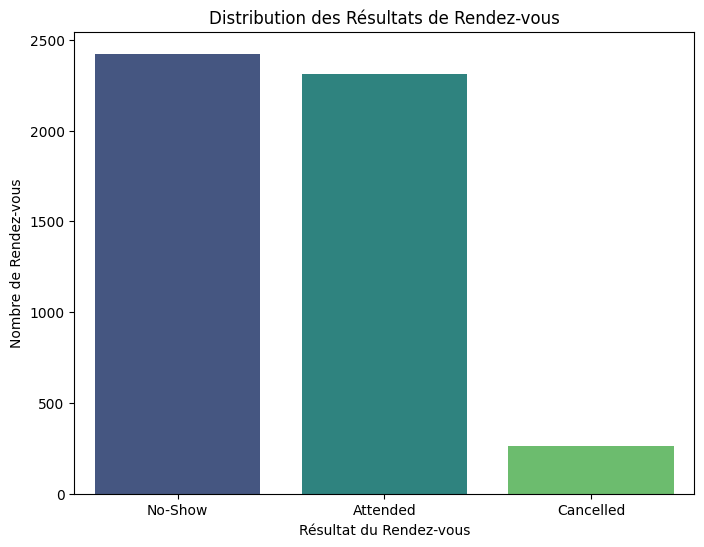

In [ ]:
outcome_counts = HC['appointment_outcome'].value_counts()
outcome_percentages = HC['appointment_outcome'].value_counts(normalize=True) * 100

print("Distribution des résultats de rendez-vous:")
print(outcome_counts)
print("\nPourcentage des résultats de rendez-vous:")
print(outcome_percentages)

fig = plt.figure(figsize=(8, 6))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette='viridis')
plt.title('Distribution des Résultats de Rendez-vous')
plt.xlabel('Résultat du Rendez-vous')
plt.ylabel('Nombre de Rendez-vous')
plt.show()

## 4-Développement de KPI et insights métier

Taux de no-show global et par segment

In [ ]:
global_no_show_rate = HC[HC['appointment_outcome'] == 'No-Show'].shape[0] / HC.shape[0] * 100
print(f"Taux de No-Show Global: {global_no_show_rate:.2f}%")

Taux de No-Show Global: 48.46%


Par Genre (gender)

In [ ]:
no_show_by_gender = HC.groupby('gender')['appointment_outcome'].value_counts(normalize=True).unstack() * 100
no_show_by_gender['No-Show'] = no_show_by_gender['No-Show'].fillna(0) # Fill NaN for categories that have no no-shows
print("Taux de No-Show par Genre:")
display(no_show_by_gender[['No-Show']].sort_values(by='No-Show', ascending=False))

Taux de No-Show par Genre:


appointment_outcome,No-Show
gender,
Male,48.710483
Female,48.432476
Prefer not to say,43.518519


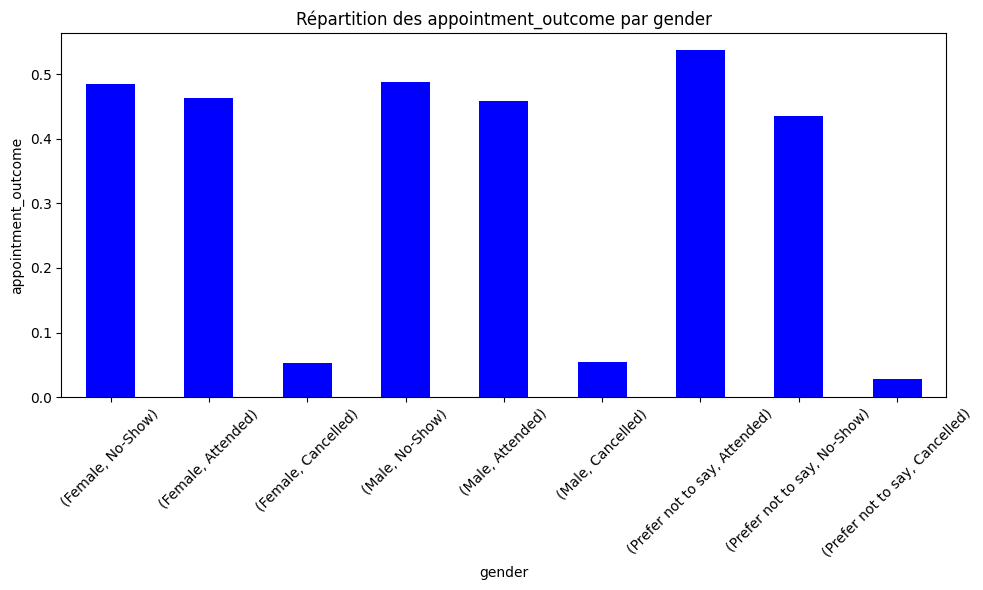

In [ ]:
HC.groupby('gender')['appointment_outcome'].value_counts(normalize=True).plot(kind = 'bar',color = 'blue',figsize= (10,6))
plt.title ('Répartition des appointment_outcome par gender')
plt.xlabel('gender')
plt.ylabel('appointment_outcome')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Par Groupe d'Âge (age_group)

In [ ]:
no_show_by_age_group = HC.groupby('age_group')['appointment_outcome'].value_counts(normalize=True).unstack() * 100
no_show_by_age_group['No-Show'] = no_show_by_age_group['No-Show'].fillna(0)
print("Taux de No-Show par'groupe d'Âge:")
display(no_show_by_age_group[['No-Show']].sort_values(by='No-Show', ascending=False))

Taux de No-Show par'groupe d'Âge:


appointment_outcome,No-Show
age_group,
55-64,50.750000
25-34,50.702427
18-24,50.177305
35-44,48.351648
45-54,48.045397
65+,45.124899


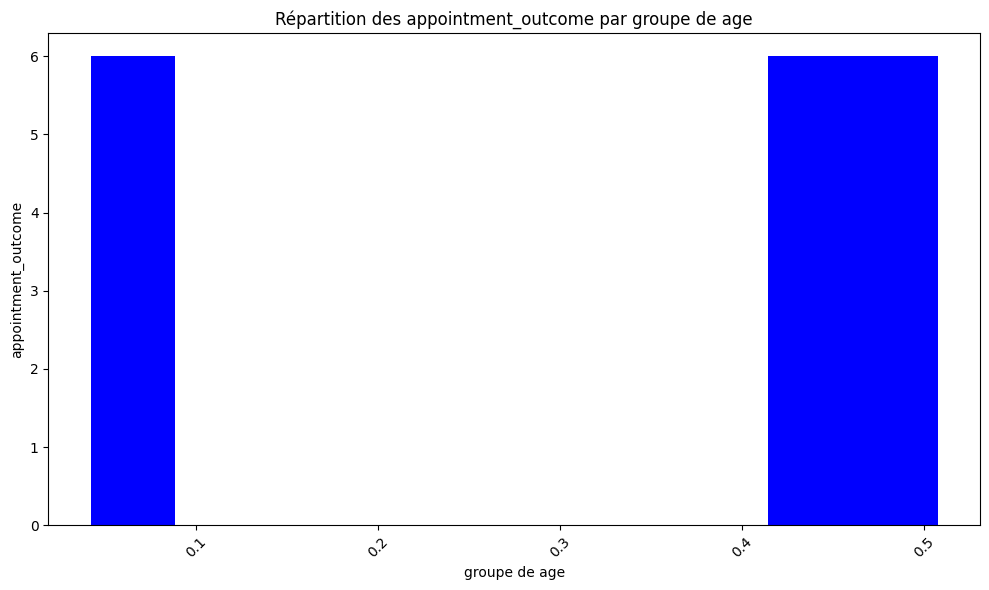

In [ ]:
HC.groupby('age_group')['appointment_outcome'].value_counts(normalize=True).plot(kind = 'hist',color = 'blue',figsize= (10,6))
plt.title ('Répartition des appointment_outcome par groupe de age')
plt.xlabel('groupe de age')
plt.ylabel('appointment_outcome')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Par Type de Rendez-vous (appointment_type)

In [ ]:
no_show_by_appointment_type = HC.groupby('appointment_type')['appointment_outcome'].value_counts(normalize=True).unstack() * 100
no_show_by_appointment_type['No-Show'] = no_show_by_appointment_type['No-Show'].fillna(0)
print("Taux de No-Show par Type de Rendez-vous:")
display(no_show_by_appointment_type[['No-Show']].sort_values(by='No-Show', ascending=False))

Taux de No-Show par Type de Rendez-vous:


appointment_outcome,No-Show
appointment_type,
Follow-up,51.231527
Diagnostic Test,49.747049
Specialist Consultation,47.444444
General Consultation,46.644295


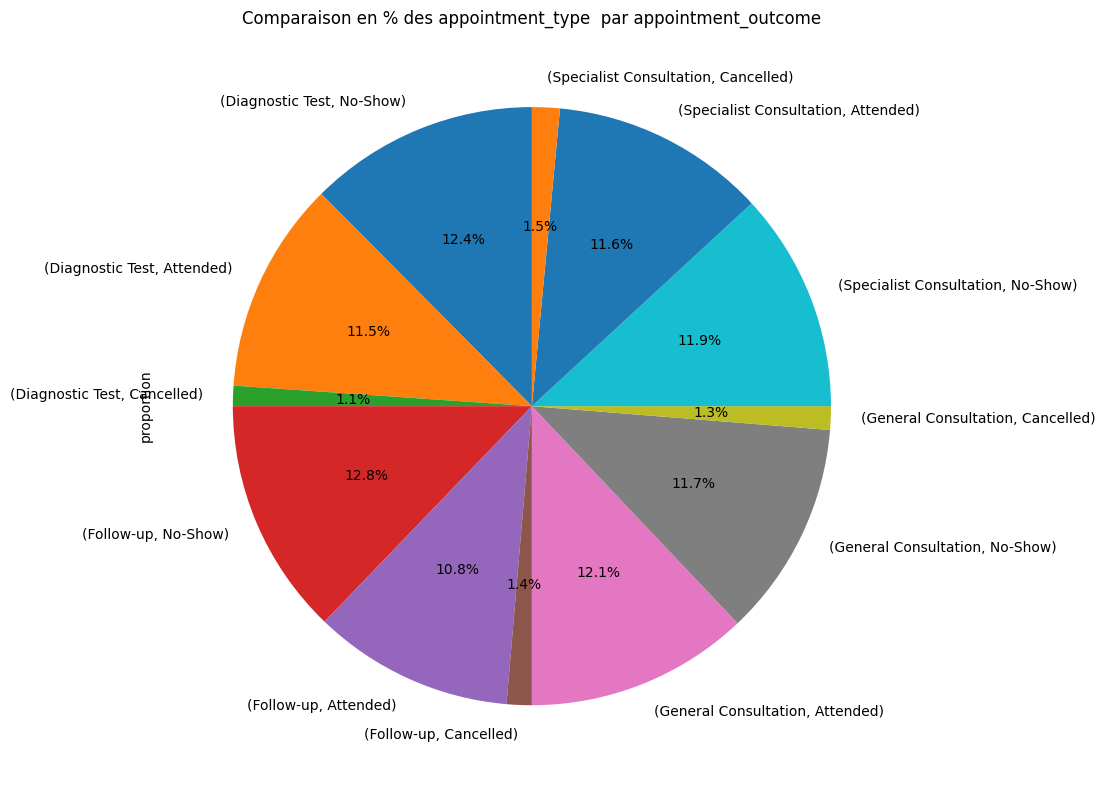

In [ ]:
HC.groupby('appointment_type')['appointment_outcome'].value_counts(normalize=True).plot(kind = 'pie',autopct = '%1.1f%%',startangle = 90,figsize= (12,8))
plt.title ('Comparaison en % des appointment_type  par appointment_outcome')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()



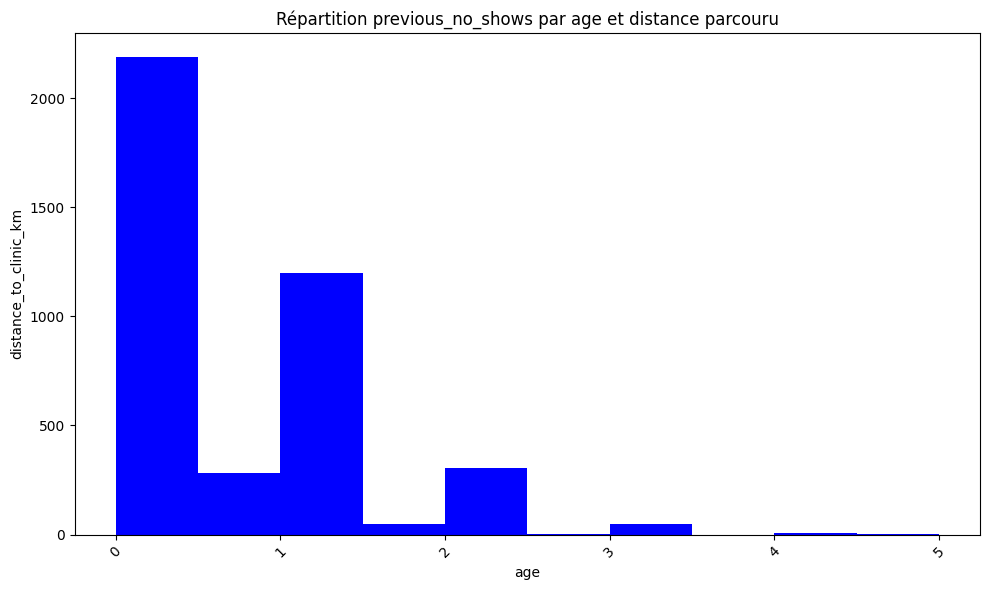

In [ ]:
HC.groupby(['age','distance_to_clinic_km'])['previous_no_shows'].mean().plot(kind = 'hist',color = 'blue',figsize= (10,6))
plt.title ('Répartition previous_no_shows par age et distance parcouru')
plt.xlabel('age')
plt.ylabel('distance_to_clinic_km')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

## Semaine 6 : ANALYTIQUE AVANCEE ET AIDE A LA DECISON

Conclusion à approfondir par rapport à semaine 5 : si ni le genre, ni l'âge, ni le type de RDV ne discriminent fortement, le vrai moteur du no-show se trouve probablement ailleurs dans des variables qui n'as pas encore été croisées avec appointment_outcome :

reminder_sent / reminder_channel (le rappel a-t-il un effet réel ?)

booking_lead_days (un délai de réservation long augmente-t-il le risque d'oubli ?)

distance_to_clinic_km (la distance décourage-t-elle la venue ?)

previous_no_shows (l'historique du patient est souvent le meilleur prédicteur)

waiting_time_minutes (un temps d'attente long lors de précédentes visites dissuade-t-il ?)


In [ ]:
HC.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-06-02,2025-02-18,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-09-07,2025-08-25,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


# **a-Le rappel à t'il un effet réel.**


In [ ]:
no_show_by_reminder_sent = HC.groupby('reminder_sent')['appointment_outcome'].value_counts(normalize=True).unstack() * 100
no_show_by_reminder_sent['No-Show'] = no_show_by_reminder_sent['No-Show'].fillna(0) # Fill NaN for categories that have no no-shows
print("Taux de No-Show par rappel:")
display(no_show_by_reminder_sent[['No-Show']].sort_values(by='No-Show', ascending=False))

Taux de No-Show par rappel:


appointment_outcome,No-Show
reminder_sent,
No,51.390922
Yes,47.358283


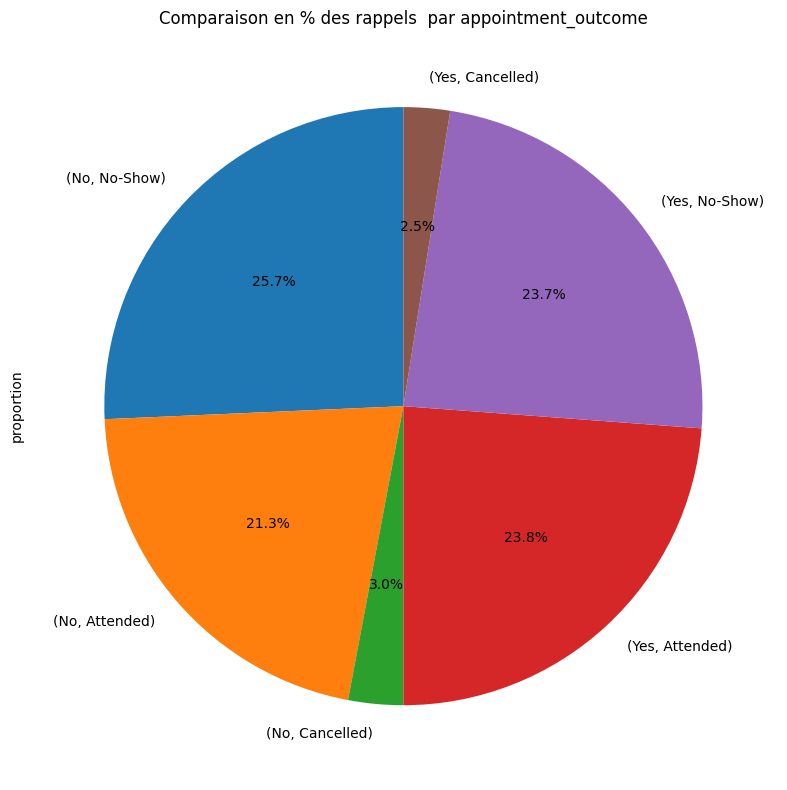

In [ ]:
HC.groupby('reminder_sent')['appointment_outcome'].value_counts(normalize=True).plot(kind = 'pie',autopct = '%1.1f%%',startangle = 90,figsize= (12,8))
no_show_by_reminder_sent['No-Show'] = no_show_by_reminder_sent['No-Show'].fillna(0) # Fill NaN for categories that have no no-shows
plt.title ('Comparaison en % des rappels  par appointment_outcome')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()


Interpretation : On constate, lorsque les rappels ne sont pas envoyés (reminder_sent = No), le taux de non-présentation ('No-Show') est d'environ 51,39%. En revanche, lorsque les rappels sont envoyés (reminder_sent = Yes), le taux de non-présentation diminue à environ 47,36%.
Cela suggère que l'envoi de rappels a un effet positif et réduit le taux de non-présentation aux rendez-vous, ce qui est un insight métier important pour améliorer la présence aux rendez-vous des patients.

# **b-un délai de réservation long augmente-t-il le risque d'oubli**

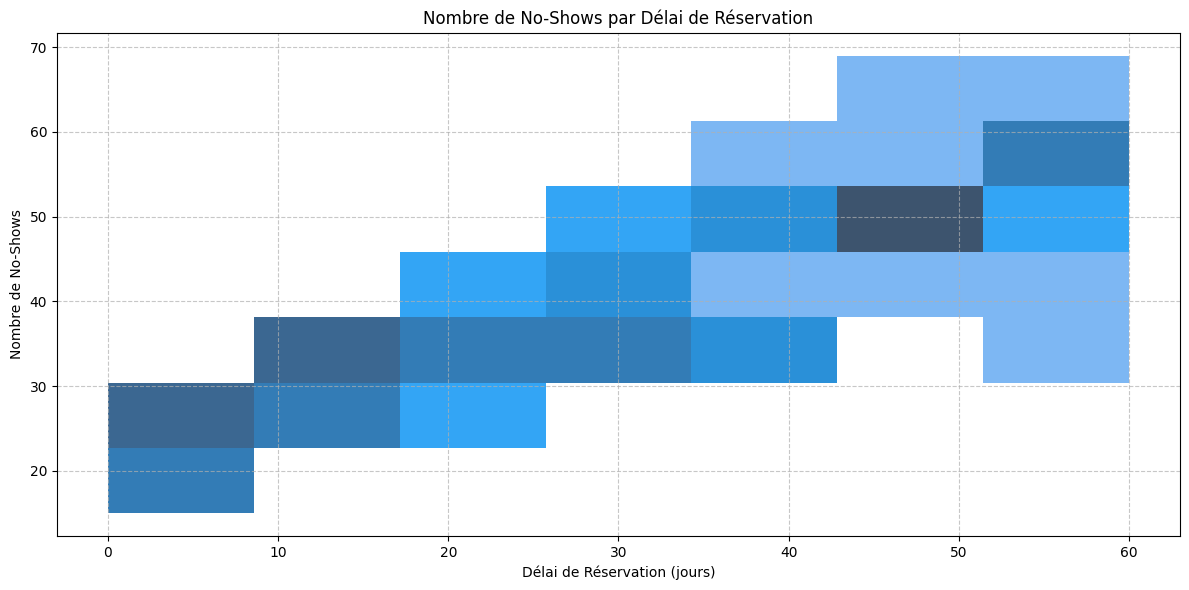

In [ ]:
no_show_by_lead_days = HC[HC['appointment_outcome'] == 'No-Show'].groupby('booking_lead_days').size().reset_index(name='no_show_count')

plt.figure(figsize=(12, 6))
sns.histplot(x='booking_lead_days', y='no_show_count', data=no_show_by_lead_days)
plt.title('Nombre de No-Shows par Délai de Réservation')
plt.xlabel('Délai de Réservation (jours)')
plt.ylabel('Nombre de No-Shows')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

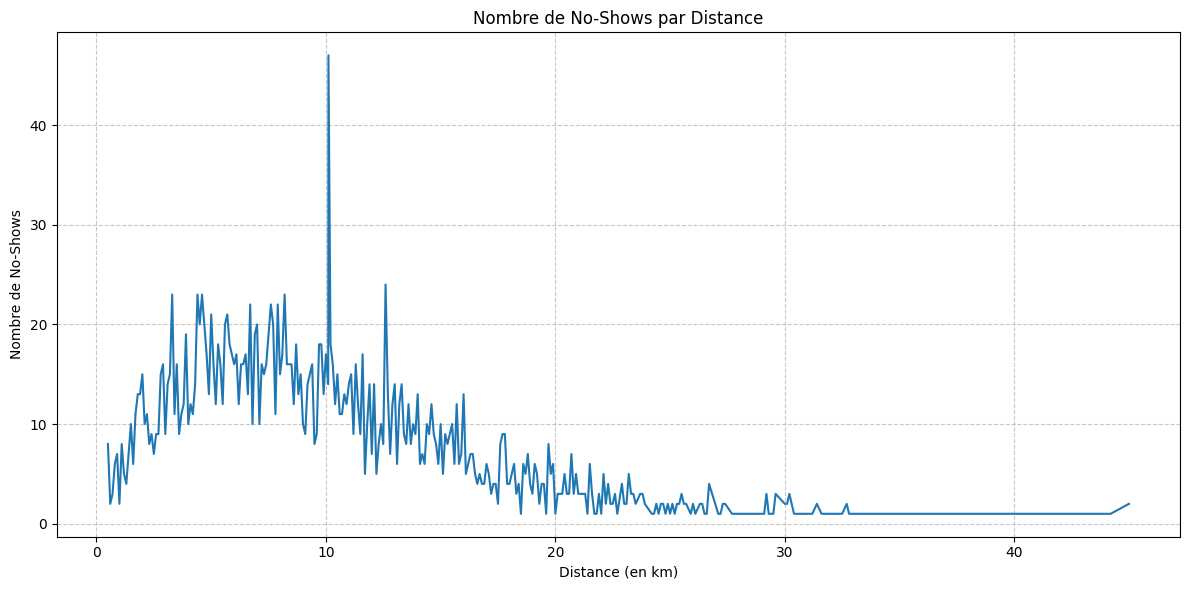

In [ ]:
no_show_by_lead_days = HC[HC['appointment_outcome'] == 'No-Show'].groupby('distance_to_clinic_km').size().reset_index(name='no_show_count')

plt.figure(figsize=(12, 6))
sns.lineplot(x='distance_to_clinic_km', y='no_show_count', data=no_show_by_lead_days)
plt.title('Nombre de No-Shows par Distance')
plt.xlabel('Distance (en km)')
plt.ylabel('Nombre de No-Shows')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Nombre de No-Shows')

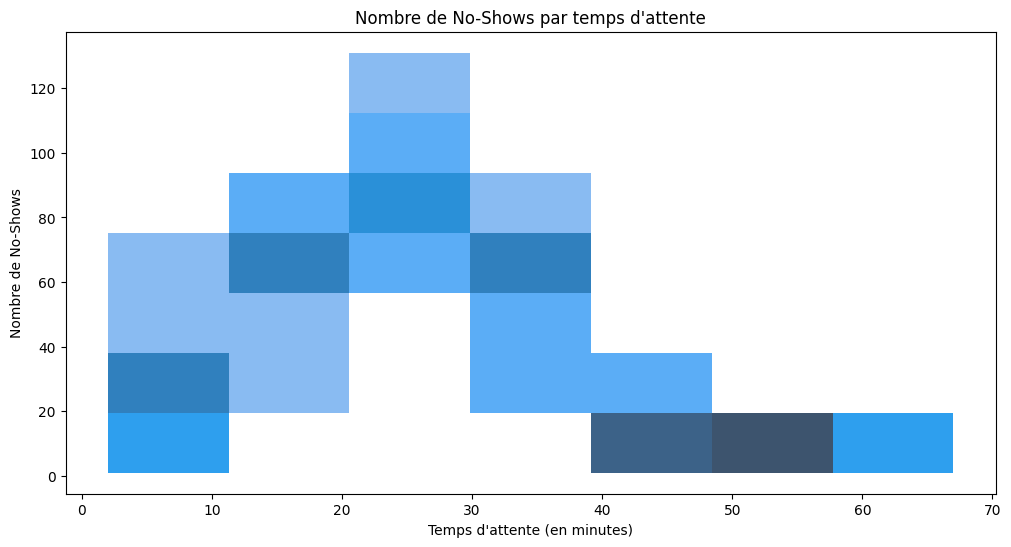

In [ ]:
no_show_by_lead_days = HC[HC['appointment_outcome'] == 'No-Show'].groupby('waiting_time_minutes').size().reset_index(name='no_show_count')

plt.figure(figsize=(12, 6))
sns.histplot(x='waiting_time_minutes', y='no_show_count', data=no_show_by_lead_days)
plt.title('Nombre de No-Shows par temps d\'attente')
plt.xlabel('Temps d\'attente (en minutes)')
plt.ylabel('Nombre de No-Shows')


Conclusion — Vers la Semaine 7

La Semaine 6 marque un tournant dans le projet HealthConnect Experience Lab : on passe d'un diagnostic descriptif à une base de travail actionnable.

Le rappel automatique reste, à ce stade, le seul levier validé statistiquement (-4,03 points de no-show), et son effet est indépendant du profil du patient — un signal fort à opérationnaliser sans attendre les tests de Semaine 7. En parallèle, on écarte progressivement les fausses pistes : ni le genre, ni l'âge, ni le type de rendez-vous n'expliquent significativement le no-show. La variable qui reste la plus prometteuse — l'historique du patient (previous_no_shows) — n'a toujours pas été testée, ce qui en fait la priorité absolue de la semaine prochaine.

Mais cette semaine a aussi révélé une limite méthodologique importante : plusieurs résultats (délai de réservation, distance, temps d'attente) reposent sur des comptages bruts et un artefact d'imputation, pas sur des taux normalisés. Autrement dit, certaines tendances qui semblent visuellement convaincantes n'ont pas encore de valeur statistique confirmée.

La Semaine 7 doit donc répondre à trois exigences avant toute recommandation finale :

Valider statistiquement — tests du Chi² et régression logistique pour confirmer (ou infirmer) la significativité des écarts observés, notamment sur booking_lead_days et previous_no_shows.
Corriger les biais de données — harmoniser l'imputation de waiting_time_minutes et normaliser les comptages en taux plutôt qu'en volumes bruts.
Construire un premier score de risque de no-show, combinant les variables réellement validées (rappel, historique du patient), pour donner aux équipes métier un outil concret de ciblage plutôt qu'une simple liste d'observations.

En résumé : la Semaine 6 a permis de trier le signal du bruit — reste maintenant à transformer ce signal en preuve statistique, puis en outil opérationnel.